# Chlorine Residual Analysis of a Municipal Water Distribution System

## Overview

This project analyzes chlorine residual data collected across a municipal water distribution system to evaluate overall disinfection performance, identify potential areas of concern, and assess spatial and temporal trends.

Chlorine residual monitoring is a critical component of drinking water quality management, ensuring that disinfectant levels remain sufficient throughout the distribution system to protect against microbial contamination.

## Objectives

The primary goals of this analysis are to:

- Evaluate whether chlorine residuals remain within typical operational targets over time
- Identify and investigate unusually low residual values
- Compare performance across sampling locations within the distribution system
- Distinguish true system behavior from data quality anomalies
- Develop visualizations that support operational decision-making

## Dataset Description

The dataset consists of field measurements of chlorine residual (mg/L) collected at routine sampling locations over multiple years. Each observation includes:

- Sample location and address
- Sampling date
- Measured chlorine residual concentration

Sampling is conducted on a rotating schedule, with each location typically measured once per week.

## Approach

The analysis is structured in several stages:

1. Data Cleaning and Validation:
   * Identification and flagging of anomalous values (e.g., near-zero residuals likely due to recording errors)
2. Time Series Analysis:
   - Evaluation of system-wide trends using daily aggregated statistics
3. Location-Level Analysis:
   - Comparison of performance across sampling sites, with classification by infrastructure type
4. Heatmap Visualization:
   - Exploration of spatial and temporal patterns using aggregated residual values
5. Low-End Residual Risk Assessment:
   - Identification of locations that most frequently approach minimum operational thresholds
  
## Key Considerations

- Sampling frequency is limited (approximately weekly per site), which influences time series interpretation
- Certain infrastructure types (e.g., pump stations, reservoirs) exhibit different expected behavior and are analyzed separately
- Data quality issues are addressed through flagging rather than removal, preserving transparency and analytical flexibility

## Outcome

The result is a comprehensive, reproducible analysis framework that provides insight into system performance and highlights areas for continued monitoring and operational awareness.

#### Step 1: Load Raw Chlorine Sampling Data


This step locates all monthly Excel files for chlorine residual (2020-2026) stored in the project directory.

Data is organized by year and will be combined into a single dataset for analysis.

In [10]:
import os
import glob

# Define base directory where raw Excel files are stored
# Note: data is stored on a OneDrive-backed Desktop
base_path = r"C:\Users\xroby\OneDrive\Desktop\chlorineproject\rawdata"

# Verify path exists and inspect folder structure
print("Base Path exists:", os.path.exists(base_path))
print("Folders inside rawdata:", os.listdir(base_path))

# Recursively locate all Excel files (.xlsx)
files = glob.glob(os.path.join(base_path, "**", "*.xlsx"), recursive=True)

# Summary check: number of files and sample file paths
print("Number of excel files found:", len(files))
print(files[:10])

Base Path exists: True
Folders inside rawdata: ['2020 BACTI SUMMARIES', '2021 BACTI SUMMARIES', '2022 BACTI SUMMARIES', '2023 BACTI SUMMARIES', '2024 BACTI SUMMARIES', '2025 BACTI SUMMARIES', '2026 BACTI SUMMARIES']
Number of excel files found: 80
['C:\\Users\\xroby\\OneDrive\\Desktop\\chlorineproject\\rawdata\\2020 BACTI SUMMARIES\\SOCWA 1-2020.xlsx', 'C:\\Users\\xroby\\OneDrive\\Desktop\\chlorineproject\\rawdata\\2020 BACTI SUMMARIES\\SOCWA 10-2020.xlsx', 'C:\\Users\\xroby\\OneDrive\\Desktop\\chlorineproject\\rawdata\\2020 BACTI SUMMARIES\\SOCWA 11-2020.xlsx', 'C:\\Users\\xroby\\OneDrive\\Desktop\\chlorineproject\\rawdata\\2020 BACTI SUMMARIES\\SOCWA 12-2020.xlsx', 'C:\\Users\\xroby\\OneDrive\\Desktop\\chlorineproject\\rawdata\\2020 BACTI SUMMARIES\\SOCWA 2-2020.xlsx', 'C:\\Users\\xroby\\OneDrive\\Desktop\\chlorineproject\\rawdata\\2020 BACTI SUMMARIES\\SOCWA 3-2020.xlsx', 'C:\\Users\\xroby\\OneDrive\\Desktop\\chlorineproject\\rawdata\\2020 BACTI SUMMARIES\\SOCWA 4-2020.xlsx', 'C:\\U

#### Inspect Sample File Structure

Before combining all Excel files, we inspect a single representative file to understand its layout and formatting.

This step helps identify:
- header formatting (e.g., extra title rows, merged cells)
- column naming consistency across files
- data types and potential cleaning requirements due to inconsistencies (e.g., text vs numeric values)

Understanding this structure ensures we can build a robust data integration and cleaning pipeline for all files.

In [11]:
import pandas as pd

# Select first file from list
test_file = files[0]

print("Testing file:")
print(test_file)

# Read Excel file
df_test = pd.read_excel(test_file)
print(df_test.head())

print("\nColumns:")
print(df_test.columns.tolist())

Testing file:
C:\Users\xroby\OneDrive\Desktop\chlorineproject\rawdata\2020 BACTI SUMMARIES\SOCWA 1-2020.xlsx
         SOUTHEASTERN OAKLAND COUNTY WATER AUTHORITY Unnamed: 1  \
0  Water Supplier Bacteriological Analysis Report...        NaN   
1                  System Name: S.O.C.W.A. WSSN-6150        NaN   
2                           Oakland County, Michigan        NaN   
3                                                NaN   Month:     
4                                                NaN        NaN   

            Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5     Unnamed: 6  \
0                  NaN        NaN        NaN        NaN            NaN   
1                  NaN        NaN        NaN        NaN            NaN   
2                  NaN        NaN        NaN        NaN            NaN   
3  2020-01-01 00:00:00        NaN        NaN        NaN  # of Weeks:     
4                  NaN        NaN        NaN        NaN            NaN   

  Unnamed: 7 Unnamed: 8 Unnamed: 9 Unnamed:

#### Identify Data Table Start Position

The source Excel files are structured as formatted reports rather than clean data tables. As a result, the actual dataset begins several rows below the top of each file (which is why we see Unnamed: 2, Unnamed: 3, etc. instead of the column names).

In this step, we inspect the raw file to:
- locate the row containing the true column headers
- determine the appropriate `header` or `skiprows` parameter for ingestion
- assess any structural inconsistencies across files

These insights allow us to design a data loading process that is scalable across all files.

In [16]:
df_test.head(20)

,SOUTHEASTERN OAKLAND COUNTY WATER AUTHORITY,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Water Supplier Bacteriological Analysis Report...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,System Name: S.O.C.W.A. WSSN-6150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Oakland County, Michigan",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Month:,2020-01-01 00:00:00,NaN,NaN,NaN,# of Weeks:,NaN,5,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Communinty,NaN,NaN,Date:,2020-01-02 00:00:00,Date:,2020-01-09 00:00:00,Date:,2020-01-16 00:00:00,Date:,2020-01-23 00:00:00,Date:,2020-01-30 00:00:00
6,(Sample Location),NaN,Sta.,Cl2,P/A,Cl2,P/A,Cl2,P/A,Cl2,P/A,Cl2,P/A
7,City of Berkley (WSSN #0630),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Einstein Bagel,27350 Woodward Ave.,BE-1,0.7,A,0.7,A,0.7,A,0.7,A,0.7,A
9,Auto One,3080 11 Mile Rd.,BE-2,0.7,A,0.7,A,0.7,A,0.7,A,0.7,A


#### Load Raw Data Without Header (Structure Analysis)

Since the Excel files are formatted as reports with metadata and multi-row headers (i.e. date in row 5, Cl2 in row 6), the default import does not correctly capture the underlying data structure.

To better understand the layout, we reload the file without assigning a header (`header=None`). This allows us to:
- inspect all rows as raw data
- identify the exact rows containing column headers
- determine where the actual dataset begins

This step is critical for building a reliable data extraction process.

In [13]:
df_raw = pd.read_excel(test_file, header=None)

pd.set_option('display.max_rows', 20)
print(df_raw.

                                                   0                    1   \
0         SOUTHEASTERN OAKLAND COUNTY WATER AUTHORITY                  NaN   
1   Water Supplier Bacteriological Analysis Report...                  NaN   
2                   System Name: S.O.C.W.A. WSSN-6150                  NaN   
3                            Oakland County, Michigan                  NaN   
4                                                 NaN             Month:     
5                                                 NaN                  NaN   
6                                          Communinty                  NaN   
7                                   (Sample Location)                  NaN   
8                       City of Berkley (WSSN  #0630)                  NaN   
9                                      Einstein Bagel  27350 Woodward Ave.   
10                                           Auto One     3080 11 Mile Rd.   
11                                       DPW Building       3226

#### Extract Header and Data Sections

Based on inspection of the raw file, the data structure is organized as follows:

- Date values appear in a header row above the data
- Each date has two associated columns: Chlorine (Cl2) and Presence/Absence (P/A)
- The actual sampling data begins several rows below these headers

To properly extract the dataset, we will:

- isolate the date row and measurement type row
- construct meaningful column names
- extract the tabular data starting from the first sample row

In [19]:
# Identify key structural rows manually
date_row = df_raw.iloc[5]
type_row = df_raw.iloc[6]

print("DATE ROW:")
print(date_row)

print("\nTYPE ROW:")
print(type_row)

DATE ROW:
0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    NaN
12    NaN
Name: 5, dtype: object

TYPE ROW:
0              Communinty
1                     NaN
2                     NaN
3                   Date:
4     2020-01-02 00:00:00
5                   Date:
6     2020-01-09 00:00:00
7                   Date:
8     2020-01-16 00:00:00
9                   Date:
10    2020-01-23 00:00:00
11                  Date:
12    2020-01-30 00:00:00
Name: 6, dtype: object


#### Refine Header Row Selection

Initial inspection showed that our first estimate of the header rows was off by one row.

After reviewing the raw structure more closely, the date values appear on row 6 and the measurements on row 7. We update the row selection accordingly.

In [20]:
# Refine header row selection based on raw structure inspection
date_row = df_raw.iloc[6]
type_row = df_raw.iloc[7]

print("DATE ROW:")
print(date_row)

print("\nTYPE ROW:")
print(type_row)

DATE ROW:
0              Communinty
1                     NaN
2                     NaN
3                   Date:
4     2020-01-02 00:00:00
5                   Date:
6     2020-01-09 00:00:00
7                   Date:
8     2020-01-16 00:00:00
9                   Date:
10    2020-01-23 00:00:00
11                  Date:
12    2020-01-30 00:00:00
Name: 6, dtype: object

TYPE ROW:
0     (Sample Location)
1                   NaN
2                  Sta.
3                   Cl2
4                   P/A
5                   Cl2
6                   P/A
7                   Cl2
8                   P/A
9                   Cl2
10                  P/A
11                  Cl2
12                  P/A
Name: 7, dtype: object


#### Construct Column Names from Multi-Row Headers

The dataset uses a multi-row header structure:
- one row contains sampling dates
- the next row contiains measurement types (Cl2, P/A)

To create meaningful column names, we combine these rows into a single header format:
`<date>_<measurement_type>`

This enables easier reshaping and analysis of the dataset.

In [22]:
# Build column names by combining date and measurement rows

column_names = []

for i in range(len(df_raw.columns)):
    date_val = date_row[i]
    type_val = type_row[i]

    # Clean values
    if pd.notna(date_val):
        date_str = str(date_val).split()[0] # Keep date only
    else: 
        date_str = ""

    if pd.notna(type_val):
        type_str = str(type_val).replace("/", "") # P/A -> PA
    else:
        type_str = ""

    # Combine
    if date_str and type_str:
        col_name = f"{date_str}_{type_str}"
    else:
        col_name = type_str or date_str or f"col_{i}"

    column_names.append(col_name)

# Show results
print(column_names)

['Communinty_(Sample Location)', 'col_1', 'Sta.', 'Date:_Cl2', '2020-01-02_PA', 'Date:_Cl2', '2020-01-09_PA', 'Date:_Cl2', '2020-01-16_PA', 'Date:_Cl2', '2020-01-23_PA', 'Date:_Cl2', '2020-01-30_PA']


#### Refine Column Construction Logic

Initial column construction revealed inconsistencies such as `"Date:_Cl2"` due to the dataset's structure:

- the label `"Date:"` and the actual date values are stored in seperate columns
- measurement types (`Cl2`, `P/A`) follow the date columns

To address this, we implement a forward-fill approach:
- track the most recent valid date value
- apply it to subsequent measurement columns

This ensures each measurement column is correctly labeled as:
`<date>_<measurement_type>`

In [27]:
column_names = []
current_date = None

for i in range(len(df_raw.columns)):
    date_val = date_row[i]
    type_val = type_row[i]

    # Update current date when we hit a real date
    if pd.notna(date_val) and "Date" not in str(date_val):
        current_date = str(date_val).split()[0]

    # Clean type
    if pd.notna(type_val):
        type_str = str(type_val).replace("/", "") # P/A -> PA
    else: 
        type_str = ""

    # Build column name
    if current_date and type_str in ["Cl2", "PA"]:
        col_name = f"{current_date}_{type_str}"
    elif type_str in ["Sta.", "(Sample Location)", "Community"]:
        col_name = type_str
    else:
        col_name = f"col_{i}"

    column_names.append(col_name)

print(column_names)

['(Sample Location)', 'col_1', 'Sta.', 'Communinty_Cl2', '2020-01-02_PA', '2020-01-02_Cl2', '2020-01-09_PA', '2020-01-09_Cl2', '2020-01-16_PA', '2020-01-16_Cl2', '2020-01-23_PA', '2020-01-23_Cl2', '2020-01-30_PA']


#### Seperate Descriptor Columns from Measurement Columns

Our output from the previous section is still showing errors like `'Community_Cl2'`. To clean this up we'll try to stop inferring the first few columns and instead handle them explicitly.

The first three columns contain site descriptors rather than date based measurements:
- Community / Sample Location
- Address
- Station ID

Because these columns do not follow the repeating date/measurement pattern, they are assigned manually. Date-based column construction is then applied only to the remaining measurement columns.

In [28]:
# Manually define the known left-side columns
column_names = ["Community", "Address", "Sta."]

# Start date-based parsing after the first 3 descriptor columns
current_date = None

for i in range(3, len(df_raw.columns)):
    date_val = date_row[i]
    type_val = type_row[i]

    # Capture actual date values only
    if pd.notna(date_val) and "Date" not in str(date_val):
        current_date = str(date_val).split()[0]

    # Clean measurement label
    if pd.notna(type_val):
        type_str = str(type_val).replace("/", "")  # P/A -> PA
    else:
        type_str = ""

    # Only create names for valid measurement columns
    if current_date and type_str in ["Cl2", "PA"]:
        col_name = f"{current_date}_{type_str}"
    else:
        col_name = f"col_{i}"

    column_names.append(col_name)

print(column_names)

['Community', 'Address', 'Sta.', 'col_3', '2020-01-02_PA', '2020-01-02_Cl2', '2020-01-09_PA', '2020-01-09_Cl2', '2020-01-16_PA', '2020-01-16_Cl2', '2020-01-23_PA', '2020-01-23_Cl2', '2020-01-30_PA']


#### Resolve Header Misalignment

This approach revealed misalignment between date values and measurement types, resulting in incorrectly labeled columns.

Inspection showed that the dataset uses a staggered structure, where `"Date:"` and the actual date values appear in adjacent columns, while measurement types ('Cl2', 'P/A') span across them. This is why we see a missing column name (`'col_3'`) and incorrect pairing of dates and measurement types (`'PA'` appearing before `'Cl2'`).

To address this, we refine the logic to correctly map each measurement column to its corresponding date, ensuring consistent and accurate column naming.

In [31]:
# Manually define the known left-side columns
column_names = ["Community", "Address", "Sta."]

# Build measurement columns two at a time
for i in range(3, len(df_raw.columns), 2):
    # Date is stored in the next cell of the date row for each pair
    date_val = date_row[i + 1] if i + 1 < len(df_raw.columns) else None

    if pd.notna(date_val):
        date_str = str(date_val).split()[0]
    else:
        date_str = f"unknown_date_{i}"

    # First column in pair = Cl2
    column_names.append(f"{date_str}_Cl2")

    # Second column in pair = PA
    if i + 1 < len(df_raw.columns):
        column_names.append(f"{date_str}_PA")

print(column_names)

['Community', 'Address', 'Sta.', '2020-01-02_Cl2', '2020-01-02_PA', '2020-01-09_Cl2', '2020-01-09_PA', '2020-01-16_Cl2', '2020-01-16_PA', '2020-01-23_Cl2', '2020-01-23_PA', '2020-01-30_Cl2', '2020-01-30_PA']


#### Extract Tabular Data

With our column names finally contstructed correctly, we can now extract the actual sampling data.

The dataset begins after the header and metadata rows, so we slice the DataFrame starting from the first row containing sample observations and assign the newly constructed column names.

In [32]:
# Extract actual data rows (skip header + metadata)
df_data = df_raw.iloc[8:].copy()

# Assign clean column names
df_data.columns = column_names

# Reset Index
df_data.reset_index(drop=True, inplace=True)

# Preview
print(df_data.head())
print(df_data.shape)

                       Community              Address  Sta. 2020-01-02_Cl2  \
0  City of Berkley (WSSN  #0630)                  NaN   NaN            NaN   
1                 Einstein Bagel  27350 Woodward Ave.  BE-1            0.7   
2                       Auto One     3080 11 Mile Rd.  BE-2            0.7   
3                   DPW Building       3226 Bacon St.  BE-3            0.7   
4         Public Safety Building     2395 12 Mile Rd.  BE-4            0.6   

  2020-01-02_PA 2020-01-09_Cl2 2020-01-09_PA 2020-01-16_Cl2 2020-01-16_PA  \
0           NaN            NaN           NaN            NaN           NaN   
1             A            0.7             A            0.7             A   
2             A            0.7             A            0.7             A   
3             A            0.7             A            0.7             A   
4             A            0.6             A            0.6             A   

  2020-01-23_Cl2 2020-01-23_PA 2020-01-30_Cl2 2020-01-30_PA  
0     

#### Clean Extracted Data

After extracting the tabular data, we perform basic cleaning steps:

- remove empty rows
- remove summary rows (e.g. "Weekly Average")
- drop rows without valid station identifiers

This ensures the dataset only contains valid sampling observations.

In [34]:
# Remove completely empty rows
df_data = df_data.dropna(how='all')

# Remove rows where Station (Sta.) is missing 
df_data = df_data[df_data["Sta."].notna()]

# Remove weekly average rows
df_data = df_data[~df_data["Community"].str.contains("Weekly", na=False)]

# Reset index after filtering
df_data.reset_index(drop=True, inplace=True)

# Preview cleaned data
print(df_data.head())
print(df_data.shape)

                Community               Address  Sta. 2020-01-02_Cl2  \
0          Einstein Bagel   27350 Woodward Ave.  BE-1            0.7   
1                Auto One      3080 11 Mile Rd.  BE-2            0.7   
2            DPW Building        3226 Bacon St.  BE-3            0.7   
3  Public Safety Building      2395 12 Mile Rd.  BE-4            0.6   
4    Valvoline Oil Change  31005 Greenfield Rd.  BH-1            0.7   

  2020-01-02_PA 2020-01-09_Cl2 2020-01-09_PA 2020-01-16_Cl2 2020-01-16_PA  \
0             A            0.7             A            0.7             A   
1             A            0.7             A            0.7             A   
2             A            0.7             A            0.7             A   
3             A            0.6             A            0.6             A   
4             A            0.7             A            0.7             A   

  2020-01-23_Cl2 2020-01-23_PA 2020-01-30_Cl2 2020-01-30_PA  
0            0.7             A            

#### Reshape Data to Long Format

Our output is now looking very clean. There is one final cleaning step that will make our dataset analysis-ready.

The dataset is currently in a wide format, where each date and measurement type is stored in seperate columns.

To enable time-series analysis and easier aggregation, we reshape the dataset into a long format with the following structure:

- one row per sample per date
- seperate columns for:
  - Date
  - Chlorine (Cl2)
  - Measurement Status (PA)

This transformation is critical for downstream analysis and visualization.

In [36]:
# Identify measurement columns
value_vars = [col for col in df_data.columns if "_" in col]

# Melt into long format
df_long = df_data.melt(
    id_vars=["Community", "Address", "Sta."],
    value_vars=value_vars,
    var_name="Date_Type",
    value_name="Value"
)

# Split Date and Type
df_long[["Date", "Type"]] = df_long["Date_Type"].str.rsplit("_", n=1, expand=True)

# Drop original combined column
df_long.drop(columns=["Date_Type"], inplace=True)

# Pivot so Cl2 and PA become columns
df_final = df_long.pivot_table(
    index=["Community", "Address", "Sta.", "Date"],
    columns="Type",
    values="Value",
    aggfunc="first"
).reset_index()

# Clean column names
df_final.columns.name = None

# Preview
print(df_final.head())
print(df_final.shape)

        Community               Address  Sta.        Date  Cl2 PA
0  $2.89 Cleaners  26079 Southfield Rd.  LV-1  2020-01-02  0.7  A
1  $2.89 Cleaners  26079 Southfield Rd.  LV-1  2020-01-09  0.7  A
2  $2.89 Cleaners  26079 Southfield Rd.  LV-1  2020-01-16  0.7  A
3  $2.89 Cleaners  26079 Southfield Rd.  LV-1  2020-01-23  0.7  A
4  $2.89 Cleaners  26079 Southfield Rd.  LV-1  2020-01-30  0.7  A
(386, 6)


#### Final Data Standardization and Renaming

After reshaping the dataset, we perform final cleaning and standardization:
 - rename columns for clarity (`Community` -> `Sample_Location` ; `Sta.` -> `Station_ID`)
 - convert `Date` to datetime format
 - convert `Cl2` to numeric values
 - ensure text fields (location, address, station, status) are properly formatted

This prepares the dataset for analysis, visualization, and modeling.

In [39]:
# Rename columns for clarity
df_final.rename(columns={"Community": "Sample_Location", "Sta.": "Station_ID"}, inplace=True)

# Convert data types
df_final["Date"] = pd.to_datetime(df_final["Date"], errors="coerce")
df_final["Cl2"] = pd.to_numeric(df_final["Cl2"], errors="coerce")

# Clean text fields
text_cols = ["Sample_Location", "Address", "Station_ID", "PA"]

for col in text_cols:
    df_final[col] = df_final[col].astype(str).str.strip()

# Final validation
print(df_final.info())
print(df_final.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386 entries, 0 to 385
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Sample_Location  386 non-null    object        
 1   Address          386 non-null    object        
 2   Station_ID       386 non-null    object        
 3   Date             386 non-null    datetime64[ns]
 4   Cl2              377 non-null    float64       
 5   PA               386 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 18.2+ KB
None
  Sample_Location               Address Station_ID       Date  Cl2 PA
0  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-02  0.7  A
1  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-09  0.7  A
2  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-16  0.7  A
3  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-23  0.7  A
4  $2.89 Cleaners  26079 Southfield Rd.      

#### Build Reusable Parsing Function

After validating the cleaning and reshaping workflow on a single file, we now convert the logic into a reusable function.

This allows us to:
- apply the same transformation process to every monthly Excel file
- standardize parsing across years
- combine all the files into one master dataset

Encapsulating the logic in a function also improves readability, scalability, and maintainability.

In [42]:
import pandas as pd
import numpy as np
import os

def parse_socwa_file(filepath):
    """
    Parse a single SOCWA monthly Excel report into a clean long-format DataFrame.
    """
    # Read raw file with no header so we can manually reconstruct structure
    df_raw = pd.read_excel(filepath, header=None)

    # Identify header rows basd on prior structure inspection
    date_row = df_raw.iloc[6]
    type_row = df_raw.iloc[7]

    # Manually define descriptor columns
    column_names = ["Community", "Address", "Sta."]

    # Build measurement columns two at a time
    for i in range(3, len(df_raw.columns), 2):
        date_val = date_row[i + 1] if i + 1 < len(df_raw.columns) else None

        if pd.notna(date_val):
            date_str = str(date_val).split()[0]
        else:
            date_str = f"unknown_date_{i}"

        column_names.append(f"{date_str}_Cl2")

        if i + 1 < len(df_raw.columns):
            column_names.append(f"{date_str}_PA")

    # Extract tabular data
    df_data = df_raw.iloc[8:].copy()
    df_data.columns = column_names
    df_data.reset_index(drop=True, inplace=True)

    # Basic Cleaning
    df_data = df_data.dropna(how="all")
    df_data = df_data[df_data["Sta."].notna()]
    df_data = df_data[~df_data["Community"].astype(str).str.contains("Weekly", na=False)]
    df_data.reset_index(drop=True, inplace=True)

    # Reshape wide -> long
    value_vars = [col for col in df_data.columns if "_" in col]

    df_long = df_data.melt(
        id_vars=["Community", "Address", "Sta."],
        value_vars=value_vars,
        var_name="Date_Type",
        value_name="Value"
    )

    df_long[["Date", "Type"]] = df_long["Date_Type"].str.rsplit("_", n=1, expand=True)
    df_long.drop(columns=["Date_Type"], inplace=True)

    df_final = df_long.pivot_table(
        index=["Community", "Address", "Sta.", "Date"],
        columns="Type",
        values="Value",
        aggfunc="first"
    ).reset_index()

    df_final.columns.name = None

    # Final renaming and type standardization
    df_final.rename(
        columns={"Community": "Sample_Location", "Sta.": "Station_ID"},
        inplace=True
    )

    df_final["Date"] = pd.to_datetime(df_final["Date"], errors="coerce")
    df_final["Cl2"] = pd.to_numeric(df_final["Cl2"], errors="coerce")

    text_cols = ["Sample_Location", "Address", "Station_ID", "PA"]
    for col in text_cols:
        df_final[col] = df_final[col].astype(str).str.strip()

    # Optional helpful metadata
    df_final["source_file"] = os.path.basename(filepath)

    return df_final

In [43]:
# Testing on the single test_file before we apply to all of the files in the dataset
test_parsed = parse_socwa_file(test_file)

print(test_parsed.head())
print(test_parsed.shape)
print(test_parsed.info())

  Sample_Location               Address Station_ID       Date  Cl2 PA  \
0  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-02  0.7  A   
1  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-09  0.7  A   
2  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-16  0.7  A   
3  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-23  0.7  A   
4  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-30  0.7  A   

         source_file  
0  SOCWA 1-2020.xlsx  
1  SOCWA 1-2020.xlsx  
2  SOCWA 1-2020.xlsx  
3  SOCWA 1-2020.xlsx  
4  SOCWA 1-2020.xlsx  
(386, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386 entries, 0 to 385
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Sample_Location  386 non-null    object        
 1   Address          386 non-null    object        
 2   Station_ID       386 non-null    object        
 3   Date             386 non-null    datetim

#### Note on missing Chlorine values

A small number of chlorine residual measurements are missing in the parsed output (377 non-null out of 386 entries). Based on operational context, these likely reflect sample locations that were not sampled during a given week or month (due to site access issues, temporary service outages, etc.) rather than parsing errors. 

These values will be retained as missing and handled appropriately in downstream analysis.

But just to confirm, let's inspect the missing chlorine values

In [45]:
missing_cl2 = test_parsed[test_parsed["Cl2"].isna()]

print("Missing Cl2 rows:", len(missing_cl2))
print(missing_cl2.head(10))

Missing Cl2 rows: 9
            Sample_Location              Address Station_ID       Date  Cl2  \
10   **from Buchanan 2.5 MG  24250 W. 8 Mile Rd.      WA-13 2020-01-02  NaN   
11   **from Buchanan 2.5 MG  24250 W. 8 Mile Rd.      WA-13 2020-01-09  NaN   
12   **from Buchanan 2.5 MG  24250 W. 8 Mile Rd.      WA-13 2020-01-16  NaN   
13   **from Buchanan 2.5 MG  24250 W. 8 Mile Rd.      WA-13 2020-01-23  NaN   
14   **from Buchanan 2.5 MG  24250 W. 8 Mile Rd.      WA-13 2020-01-30  NaN   
27    **from Webster 7.5 MG  3910 W. Webster Rd.       WA-5 2020-01-16  NaN   
28    **from Webster 7.5 MG  3910 W. Webster Rd.       WA-5 2020-01-23  NaN   
29    **from Webster 7.5 MG  3910 W. Webster Rd.       WA-5 2020-01-30  NaN   
155            Examined by:    Laurence Westmore          , 2020-01-16  NaN   

        PA        source_file  
10     OOS  SOCWA 1-2020.xlsx  
11     OOS  SOCWA 1-2020.xlsx  
12     OOS  SOCWA 1-2020.xlsx  
13     OOS  SOCWA 1-2020.xlsx  
14     OOS  SOCWA 1-2020.xlsx

#### Operational Interpretation of Missing Chlorine Values

Inspection of the missing chlorine residual values confirmed that these are not parsing errors. Instead, they reflect known operational conditions:

- **Buchanan 2.5 MG reservoir** is out of service and has not been used for an extended period, so samples are recorded as not collected.
- **Webster 7.5 MG reservoir** is seasonally taken offline during winter months as demand decreases; during this period, storage demand is met by the Webster elevated tank and Webster 10 MG reservoir.
- As a result, missing chlorine values in these cases represent operationally meaningful missingness rather than data quality issues.

These records will be retained in the dataset, since out-of-service and seasonally offline assets are relevant to system operations and should not be treated as parsing failures.

#### Finalize Reusable Parsing Function

After inspecting the report structure, we see the source reports include non-sample footer content such as signature fields, review labels, and other metadata that can appear within the extracted table region (i.e. "Examined by: Laurence Westmore")

These rows do not represent valid sampling observations and must be removed before final analysis.

To handle this safely, we apply: 
- a pre-reshape filter to remove obvious non-sample rows from the extracted table
- a post-reshape filter as a safeguard against any remaining report artifacts

**The following function supersedes the earlier exploratory parsing attempts and serves as the production-ready parser used for all files.**

In [53]:
import pandas as pd
import os

def parse_socwa_file(filepath):
    """
    Parse a single SOCWA monthly Excel report into a clean long-format DataFrame.
    """
    
    # 1. Read raw Excel file
    df_raw = pd.read_excel(filepath, header=None, engine="openpyxl")

    # 2. Identify header rows
    # Based on prior structure inspection:
    # - row 6 contains dates
    # - row 7 contains measurement types
    date_row = df_raw.iloc[6]
    type_row = df_raw.iloc[7]

    # 3. Reconstruct column names
    # First three columns are fixed descriptor fields
    # Remaining columns follow repeating date pairs:
    #   Cl2, PA
    column_names = ["Community", "Address", "Sta."]

    for i in range(3, len(df_raw.columns), 2):
        date_val = date_row[i + 1] if i + 1 < len(df_raw.columns) else None

        if pd.notna(date_val):
            date_str = str(date_val).split()[0]
        else:
            date_str = f"unknown_date_{i}"

        column_names.append(f"{date_str}_Cl2")

        if i + 1 < len(df_raw.columns):
            column_names.append(f"{date_str}_PA")

    # 4. Extract tabular data rows
    # Data begins below header / metadata rows
    df_data = df_raw.iloc[8:].copy()
    df_data.columns = column_names
    df_data.reset_index(drop=True, inplace=True)

    # 5. Basic cleaning
    df_data = df_data.dropna(how="all")

    # Remove summary rows
    df_data = df_data[
        ~df_data["Community"].astype(str).str.contains("Weekly", case=False, na=False)
    ]

    # Remove footer / signature / report artifact rows
    artifact_patterns = [
        "Examined by",
        "Approved by",
        "Collected by",
        "Reviewed by",
        "Authorized by",
        "WSN",
        "System Name",
        "Oakland County",
        "Bacteriological Analysis Report"
    ]
    pattern_regex = "|".join(artifact_patterns)

    df_data = df_data[
        ~df_data["Community"].astype(str).str.contains(pattern_regex, case=False, na=False)
    ]

    df_data = df_data[
        ~df_data["Address"].astype(str).str.contains(pattern_regex, case=False, na=False)
    ]

    # Keep only rows with a station identifier
    df_data = df_data[df_data["Sta."].notna()]
    df_data = df_data[
        ~df_data["Sta."].astype(str).str.contains("Date:|Month:|Weeks|nan", case=False, na=False)
    ]

    df_data.reset_index(drop=True, inplace=True)

    # 6. Reshape wide -> long
    value_vars = [col for col in df_data.columns if "_" in col]

    df_long = df_data.melt(
        id_vars=["Community", "Address", "Sta."],
        value_vars=value_vars,
        var_name="Date_Type",
        value_name="Value"
    )

    df_long[["Date", "Type"]] = df_long["Date_Type"].str.rsplit("_", n=1, expand=True)
    df_long.drop(columns=["Date_Type"], inplace=True)

    # 7. Pivot so Cl2 and PA become columns
    df_final = df_long.pivot_table(
        index=["Community", "Address", "Sta.", "Date"],
        columns="Type",
        values="Value",
        aggfunc="first"
    ).reset_index()

    df_final.columns.name = None

    # 8. Final renaming
    df_final.rename(
        columns={"Community": "Sample_Location", "Sta.": "Station_ID"},
        inplace=True
    )

    # 9. Standardize data types
    df_final["Date"] = pd.to_datetime(df_final["Date"], errors="coerce")
    df_final["Cl2"] = pd.to_numeric(df_final["Cl2"], errors="coerce")

    text_cols = ["Sample_Location", "Address", "Station_ID", "PA"]
    for col in text_cols:
        df_final[col] = df_final[col].astype(str).str.strip()

    # 10. Post-reshape safeguard
    # Remove any remaining report artifact rows
    df_final = df_final[
        ~df_final["Sample_Location"].astype(str).str.contains(
            "Examined by|Approved by|Collected by|Reviewed by|System Name|Bacteriological Analysis Report",
            case=False,
            na=False
        )
    ]

    df_final = df_final[
        ~df_final["Address"].astype(str).str.contains(
            "Laurence|Date:|Month:|Weeks",
            case=False,
            na=False
        )
    ]

    df_final = df_final[
        ~df_final["Station_ID"].astype(str).str.contains(
            "Date:|Month:|Weeks|nan",
            case=False,
            na=False
        )
    ]

    df_final.reset_index(drop=True, inplace=True)

    # 11. Add source metadata
    df_final["source_file"] = os.path.basename(filepath)

    return df_final

In [54]:
# Testing once again on the single test_file
test_parsed = parse_socwa_file(test_file)

print(test_parsed.head())
print(test_parsed.shape)
print(test_parsed.info())

  Sample_Location               Address Station_ID       Date  Cl2 PA  \
0  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-02  0.7  A   
1  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-09  0.7  A   
2  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-16  0.7  A   
3  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-23  0.7  A   
4  $2.89 Cleaners  26079 Southfield Rd.       LV-1 2020-01-30  0.7  A   

         source_file  
0  SOCWA 1-2020.xlsx  
1  SOCWA 1-2020.xlsx  
2  SOCWA 1-2020.xlsx  
3  SOCWA 1-2020.xlsx  
4  SOCWA 1-2020.xlsx  
(385, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385 entries, 0 to 384
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Sample_Location  385 non-null    object        
 1   Address          385 non-null    object        
 2   Station_ID       385 non-null    object        
 3   Date             385 non-null    datetim

In [55]:
# Validating artifact cleanup
print(
    test_parsed[
        test_parsed["Sample_Location"].str.contains("Examined|Approved|Collected", case=False, na=False)
    ]
)

print(
    test_parsed[
        test_parsed["Address"].str.contains("Laurence|Date:", case=False, na=False)
    ]
)

Empty DataFrame
Columns: [Sample_Location, Address, Station_ID, Date, Cl2, PA, source_file]
Index: []
Empty DataFrame
Columns: [Sample_Location, Address, Station_ID, Date, Cl2, PA, source_file]
Index: []


In [56]:
# Parsing all files in the dataset

all_data = []
failed_files = []

for file in files:
    try:
        df = parse_socwa_file(file)
        all_data.append(df)
    except Exception as e:
        failed_files.append((file, str(e)))

df_all = pd.concat(all_data, ignore_index=True)

print("Parsed files:", len(all_data))
print("Failed files:", len(failed_files))
print("Master dataset shape:", df_all.shape)

Parsed files: 78
Failed files: 2
Master dataset shape: (26112, 7)


In [58]:
# Inspecting the failed files

failed_files

[('C:\\Users\\xroby\\OneDrive\\Desktop\\chlorineproject\\rawdata\\2025 BACTI SUMMARIES\\~$SOCWA 5-2025.xlsx',
  'File is not a zip file'),
 ('C:\\Users\\xroby\\OneDrive\\Desktop\\chlorineproject\\rawdata\\2025 BACTI SUMMARIES\\~$SOCWA 8-2025.xlsx',
  'File is not a zip file')]

#### Handling File Parsing Errors

During batch processing, two files failed to parse. Inspection of these files revealed that they were temporary Excel lock files (prefixed with "~$"), which are automatically generated when a workbook is open and do not contain valid data.

These files are system-generated artifacts and do not represent actual data files, so they are excluded from processing.

In [59]:
# To ensure proper processing, we exclude temporary Excel files before parsing
files = [
    f for f in files
    if not os.path.basename(f).startswith("~$")
]

In [61]:
# And then re-run parsing with the cleaned file list

all_data = []
failed_files = []

for file in files:
    try:
        df = parse_socwa_file(file)
        all_data.append(df)
    except Exception as e:
        failed_files.append((file, str(e)))

df_all = pd.concat(all_data, ignore_index=True)

print("Parsed files:", len(all_data))
print("Failed files:", len(failed_files))
print("Master dataset shape:", df_all.shape)

Parsed files: 78
Failed files: 0
Master dataset shape: (26112, 7)


## Data Preparation Summary & Next Steps

At this stage, we have successfully transformed a large collection of semi-structured Excel reports into a single, clean, analysis-ready dataset.

### Key steps completed:
- Parsed multi-sheet Excel reports with inconsistent formatting
- Reconstructed column headers from multi-row structures
- Cleaned and standardized key fields (dates, chlorine values, station identifiers)
- Removed non-data artifacts (e.g., summary rows, signatures, temporary files)
- Consolidated all files into a single dataset

The resulting dataset contains:
- One row per sample location per date
- Clean numeric chlorine residual values (Cl2)
- Categorical compliance indicators (PA = Presence/Absence of Coliform)
- Consistent identifiers for location, address, and station

## Next Steps: Exploratory Data Analysis

With a clean dataset prepared, we now explore:
- Trends in chlorine residual levels over time
- Differences across sample locations and systems
- Potential anomalies or out-of-range values

This analysis will help identify patterns in water quality and lay the foundation for further monitoring and compliance checks.

#### Regulatory Context (EGLE Guidelines)

We begin by exploring the distribution of chlorine residual values (Cl2) to understand typical levels, variability, and potential outliers.

Chlorine residual is a critical indicator of water quality, and maintaining appropriate levels is essential for regulatory compliance and public safety.

In Michigan, EGLE's regulatory guidelines require a detectable level of chlorine residual throughout the entire distribution system to ensure continued disinfection. While the maximum residual disinfectant level (MRDL) based on EPA regulations is 4.0 mg/L (4 ppm) for chlorine, operational targets typically fall within a range of 0.2 mg/L to 1.0 mg/L within the distribution system. 

Values that are too low may indicate insufficient disinfection, while excessively high values can impact taste, odor, and regulatory compliance.

This context provides a benchmark for evaluating whether observed chlorine levels fall within expected operational ranges.

In [62]:
# Summary statistics for chlorine residual levels
print(df_all["Cl2"].describe())

count    25550.000000
mean         0.656685
std          0.088475
min          0.000000
25%          0.600000
50%          0.700000
75%          0.700000
max          1.200000
Name: Cl2, dtype: float64


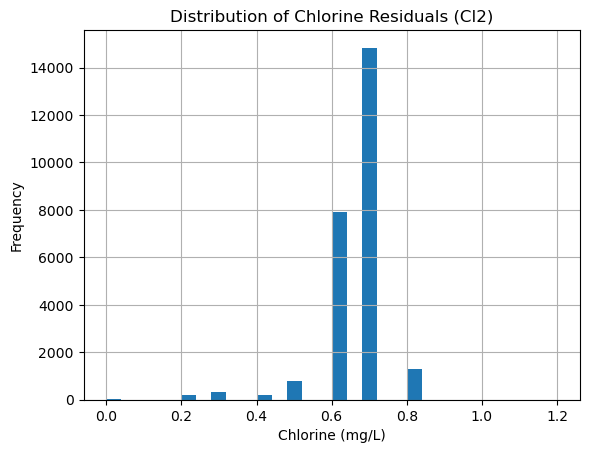

In [63]:
# Histogram for chlorine residuals
import matplotlib.pyplot as plt

plt.figure()
df_all["Cl2"].hist(bins=30)
plt.title("Distribution of Chlorine Residuals (Cl2)")
plt.xlabel("Chlorine (mg/L)")
plt.ylabel("Frequency")
plt.show()

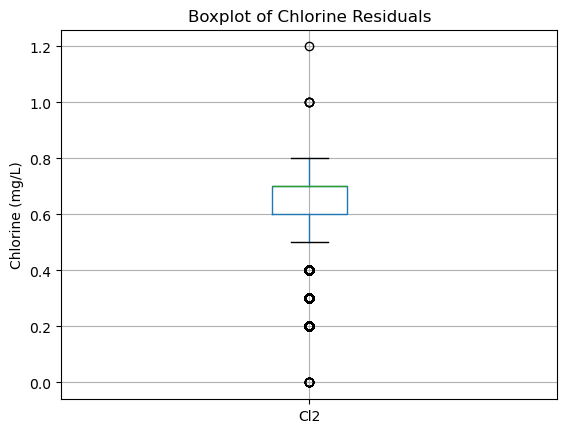

In [64]:
# Boxplot of Chlorine Residuals

plt.figure()
df_all.boxplot(column="Cl2")
plt.title("Boxplot of Chlorine Residuals")
plt.ylabel("Chlorine (mg/L)")
plt.show()

#### Key Observations

Just as I've observed during my personal experience collecting field samples, the distribution of chlorine residual values is tightly concentrated between 0.6-0.7 mg/L, indicating a remarkably consistent and well-controlled disinfection process across the system. 

Lower residual values (0.4-0.5 mg/L) are primarily observed at known system dead ends, which is consistent with expected chlorine decay in low-flow or terminal areas of the distribution network. 

A small number of unusually low values (including near 0.0 mg/L) were identified and warrant further investigation. These may represent true low-residual events, operational anomalies, or data recording issues.

Overall, the system appears to maintain chlorine residuals within typical operational targets (0.2-1.0 mg/L), with limited variability.

In [65]:
# Investigating possible explanations for the low-end outliers
# 1. True Zero Residual - loss of disinfectant and potentially serious compliance issue
# 2. Measurement/Recording Issue - missed sample incorrectly recorded as 0 instead of NaN, or simply a transcription error
# 3. Operational Context - sample taken before adequately flushing the line and/or taken at a problematic endpoint

low_cl2 = df_all[df_all["Cl2"] <= 0.1]
print(low_cl2.sort_values("Cl2").head(20))

            Sample_Location               Address Station_ID       Date  Cl2  \
5480            Howie Glass      940 Campbell Rd.       RO-8 2021-12-16  0.0   
6481            Howie Glass      940 Campbell Rd.       RO-8 2022-03-17  0.0   
7867            Howie Glass      940 Campbell Rd.       RO-8 2022-06-16  0.0   
10254           Howie Glass      940 Campbell Rd.       RO-8 2022-12-15  0.0   
11871           Howie Glass      940 Campbell Rd.       RO-8 2022-06-16  0.0   
12872           Howie Glass      940 Campbell Rd.       RO-8 2022-09-15  0.0   
14797           Howie Glass      940 Campbell Rd.       RO-8 2023-03-16  0.0   
15798           Howie Glass      940 Campbell Rd.       RO-8 2023-06-15  0.0   
16491           Howie Glass      940 Campbell Rd.       RO-8 2023-08-17  0.0   
17513     Lamb Pump Station  21101 Greenfield Rd.       WA-2 2024-10-24  0.0   
19035  **from Webster 10 MG   3910 W. Webster Rd.       WA-4        NaT  0.0   

        PA         source_file  
5480  

#### Investigation of Near-Zero Chlorine Residuals

A total of 11 observations out of ~25k+ were identified with chlorine residual values at or below 0.1 mg/L, representing a very small fraction of the overall dataset.

Closer inspection revealed that:
- 9 of these observations originated from a single location (Howie Glass) across multiple dates
- The other observation occurred at a location (Lamb Pump Station) that typically exhibits stable residuals (~0.7 mg/L)
- One record (at Webster 10 MG) contained a missing or invalid date, indicating a likely data entry issue

Based on domain knowledge and operational experience:
- These locations are not true dead ends and typically reach normal residual levels after minimal flushing times
- No known system conditions would support repeated true zero-residual events at these sites

Therefore, these low values are most likely attributable to:
- Data recording or transcription errors
- Missed samples incorrectly logged as zero
- Non-representative sampling conditions

Rather than removing the identified near-zero chlorine residual values, these observations will be retained in the dataset but flagged as potential data quality anomalies rather than true system performance issues.

This approach preserves the integrity of the original dataset while allowing downstream analysis to include or exclude anomolous values as needed, quantify the frequency of potential data issues, and maintain transparency in data handling decisions.

In [69]:
# Add a flagged column for potential data quality anomalies

df_all["low_cl2_flag"] = df_all["Cl2"] <= 0.1

# Quick validation to confirm number of flagged observations

int(df_all["low_cl2_flag"].sum())

11

### Time Series Analysis of Chlorine Residuals

To evaluate system performance over time, we examine trends in chlorine residual levels across the entire dataset.

This analysis helps identify:
- overall stability of chlorine residuals
- potential seasonal patterns
- any gradual drift or anomalies over time

We begin by aggregating chlorine residual values by date to observe system-wide trends.

In [70]:
# Aggregate chlorine residuals by date (system-wide average)
daily_avg = df_all.groupby("Date")["Cl2"].mean().reset_index()

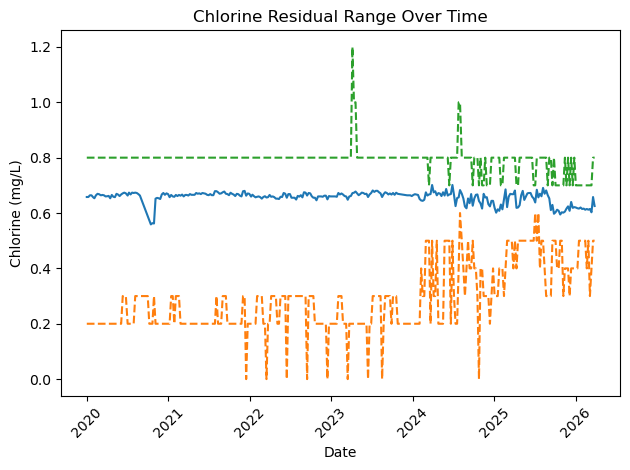

In [71]:
# Plot time series
daily_stats = df_all.groupby("Date")["Cl2"].agg(["min", "mean", "max"]).reset_index()

plt.figure()
plt.plot(daily_stats["Date"], daily_stats["mean"])
plt.plot(daily_stats["Date"], daily_stats["min"], linestyle="--")
plt.plot(daily_stats["Date"], daily_stats["max"], linestyle="--")
plt.title("Chlorine Residual Range Over Time")
plt.xlabel("Date")
plt.ylabel("Chlorine (mg/L)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Refining Time Series by Excluding Data Quality Anomalies

To better reflect true system performance, we generate a secondary time series excluding observations flagged as potential data quality anomalies (Cl2 ≤ 0.1 mg/L).

This allows us to:
- remove the influence of likely recording errors
- better visualize the operational range of chlorine residuals
- distinguish true system behavior from data artifacts

The original dataset is preserved, and all exclusions are fully traceable via the anomaly flag.

In [72]:
# Create cleaned dataset excluding flagged anomalies
df_clean = df_all[~df_all["low_cl2_flag"]].copy()

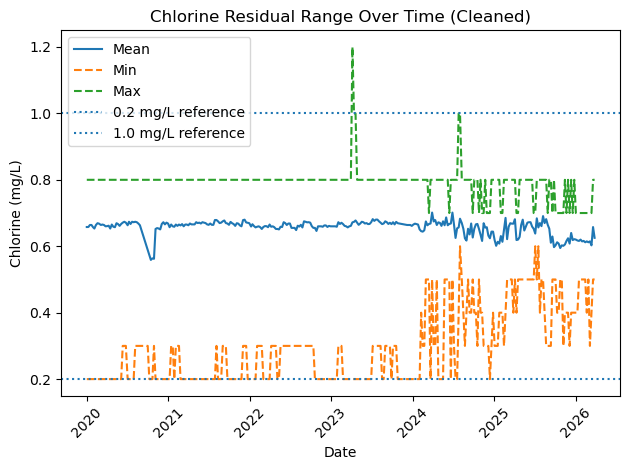

In [74]:
# Run time series on cleaned dataset

plt.figure()

plt.plot(daily_stats_clean["Date"], daily_stats_clean["mean"], label="Mean")
plt.plot(daily_stats_clean["Date"], daily_stats_clean["min"], linestyle="--", label="Min")
plt.plot(daily_stats_clean["Date"], daily_stats_clean["max"], linestyle="--", label="Max")

# EGLE / operational reference lines
plt.axhline(0.2, linestyle=":", label="0.2 mg/L reference")
plt.axhline(1.0, linestyle=":", label="1.0 mg/L reference")

plt.title("Chlorine Residual Range Over Time (Cleaned)")
plt.xlabel("Date")
plt.ylabel("Chlorine (mg/L)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### Interpretation of Cleaned Time Series

After excluding observations flagged as potential data quality anomalies (Cl2 ≤ 0.1 mg/L), the time series provides a clearer view of true system performance.

Key observations:

- Mean chlorine residuals remain highly stable over time, generally centered around ~0.63–0.66 mg/L.
- In earlier years, minimum residual values often fell in the ~0.2–0.3 mg/L range, while in the most recent three years they more commonly remained in the ~0.3–0.5 mg/L range.
- This suggests improved consistency at the low end of the distribution, with fewer locations approaching minimum operational thresholds.
- Occasional increases in maximum values (approaching ~1.0–1.2 mg/L) likely reflect localized operational conditions or adjustments rather than system-wide instability.

Overall, the cleaned time series indicates that the system maintains stable chlorine residuals across time, with evidence that lower-end residual performance may have improved in recent years.

### Identifying Lower-Performing Sample Locations

To better understand system performance at the location level, we evaluate average chlorine residuals across all sample sites.

This helps identify:
- Locations that consistently operate at the lower end of acceptable ranges
- Areas that may require operational attention (e.g., flushing, booster adjustments)
- Potential structural characteristics of the distribution system (dead ends, low flow zones)

In [75]:
# Aggregate performance by location
location_stats = (
    df_clean
    .groupby("Sample_Location")["Cl2"]
    .agg(["mean", "min", "max", "std", "count"])
    .sort_values("mean")  # lowest performers first
)

# Preview worst performers
location_stats.head(10)

,mean,min,max,std,count
Sample_Location,,,,,
Buchanan Pump Station,0.392145,0.3,0.7,0.128860,331
Lamb Pump Station,0.437278,0.2,0.8,0.217419,338
Livernois Pump Station,0.505015,0.2,0.8,0.170810,339
Gordon's Food,0.561429,0.5,0.7,0.078561,70
RO DPS,0.564012,0.3,0.7,0.072995,339
**from Webster 7.5 MG,0.566443,0.2,1.0,0.173832,149
**from Webster 10 MG,0.580415,0.2,1.2,0.123572,337
Police Station,0.594248,0.3,0.7,0.050515,678
Fire Station Wood/13,0.605015,0.3,0.7,0.046201,339


#### Refining Location-Level Analysis

Initial results revealed several inconsistencies driven by:

- Ambiguous location names (e.g., "Police Station", "D.P.W.") lacking city-level context
- Inclusion of historical sample locations no longer present in the current sampling plan
- Older observations influencing performance metrics for locations that have since stabilized

To ensure relevance and accuracy, the analysis was refined by:

- Filtering to recent data (post-2022) to reflect current system conditions
- Grouping by both sample location and address to uniquely identify sampling points

Additionally, alternative performance indicators (such as minimum observed residuals) were considered to better capture known system characteristics, particularly at distribution dead ends.

In [81]:
# Focus on recent, relevant data
df_recent = df_clean[df_clean["Date"] >= "2023-01-01"].copy()

# Group by BOTH location + address (fix ambiguity)
location_stats = (
    df_recent
    .groupby(["Sample_Location", "Address"])["Cl2"]
    .agg(["mean", "min", "max", "std", "count"])
    .sort_values("mean")
)

location_stats.reset_index().head(10)

,Sample_Location,Address,mean,min,max,std,count
0,Buchanan Pump Station,24250 W. 8 Mile Rd.,0.470238,0.3,0.7,0.138668,168
1,Livernois Pump Station,224 Livernois Rd.,0.520238,0.2,0.8,0.181662,168
2,Lamb Pump Station,21101 Greenfield Rd.,0.529341,0.2,0.8,0.199792,167
3,RO DPS,1600 Campbell Rd.,0.573214,0.3,0.7,0.068756,168
4,Walgreens,28901 Greenfield Rd.,0.590476,0.2,0.7,0.099843,168
5,DPW,19101 12 Mile Rd.,0.604348,0.2,0.7,0.113259,138
6,Police Station,425 Livernois Rd.,0.605952,0.5,0.7,0.049793,168
7,Police Station,151 Martin St.,0.607738,0.5,0.7,0.052480,168
8,**from Webster 7.5 MG,3910 W. Webster Rd.,0.609722,0.2,1.0,0.197277,72
9,Fire Station Wood/13,31000 Woodward Ave.,0.616071,0.4,0.7,0.051714,168


In [79]:
# Comparing results for lowest min values vs the above lowest mean values
location_stats.sort_values("min").head(10)

,,mean,min,max,std,count
Sample_Location,Address,,,,,
Livernois Pump Station,224 Livernois Rd.,0.520238,0.2,0.8,0.181662,168
Lamb Pump Station,21101 Greenfield Rd.,0.529341,0.2,0.8,0.199792,167
**from Gare 4.5 MG,24570 W. 12 Mile Rd.,0.649405,0.2,0.8,0.090902,168
Walgreens,28901 Greenfield Rd.,0.590476,0.2,0.7,0.099843,168
DPW,19101 12 Mile Rd.,0.604348,0.2,0.7,0.113259,138
**from Webster 7.5 MG,3910 W. Webster Rd.,0.609722,0.2,1.0,0.197277,72
Burger King,26211 12 Mile Rd.,0.621429,0.2,0.8,0.108414,168
**from Webster 10 MG,3910 W. Webster Rd.,0.617365,0.2,1.2,0.126101,167
Buchanan Pump Station,24250 W. 8 Mile Rd.,0.470238,0.3,0.7,0.138668,168


#### Classifying Sample Locations by Infrastructure Type

To improve interpretability of location-level performance, sample sites are categorized based on their role within the distribution system (e.g., Pump Station, Reservoir, Distribution).

This allows for more meaningful comparisons by ensuring that locations with different operational characteristics are not evaluated together.

In [82]:
# Create a "location type" column
def classify_location(name):
    name = str(name).lower()
    
    if "pump" in name:
        return "Pump Station"
    elif "mg" in name:
        return "Reservoir"
    elif "tank" in name:
        return "Tank"
    else:
        return "Distribution"

df_recent["Location_Type"] = df_recent["Sample_Location"].apply(classify_location)

In [83]:
# Filter by distribution only
df_dist = df_recent[df_recent["Location_Type"] == "Distribution"]

In [85]:
# Re-run the table, this time focusing on distribution points
location_stats = (
    df_dist
    .groupby(["Sample_Location", "Address"])["Cl2"]
    .agg(["mean", "min", "max", "std", "count"])
    .sort_values("mean")
)

location_stats.head(10)

mean  min  max       std  \
Sample_Location           Address                                              
RO DPS                    1600 Campbell Rd.     0.573214  0.3  0.7  0.068756   
Walgreens                 28901 Greenfield Rd.  0.590476  0.2  0.7  0.099843   
DPW                       19101 12 Mile Rd.     0.604348  0.2  0.7  0.113259   
Police Station            425 Livernois Rd.     0.605952  0.5  0.7  0.049793   
                          151 Martin St.        0.607738  0.5  0.7  0.052480   
Fire Station Wood/13      31000 Woodward Ave.   0.616071  0.4  0.7  0.051714   
Burger King               26211 12 Mile Rd.     0.621429  0.2  0.8  0.108414   
Marathon Gas              20020 8Mile Rd.       0.623188  0.5  0.7  0.047245   
D.P.W.                    92 Amherst St.        0.623214  0.5  0.8  0.051298   
Chesterfield Fire Station 1600 W. Maple Rd.     0.625595  0.5  0.7  0.045117   

                                                count  
Sample_Location           Address                      
RO DPS                    1600 Campbell Rd.       168  
Walgreens                 28901 Greenfield Rd.    168  
DPW                       19101 12 Mile Rd.       138  
Police Station            425 Livernois Rd.       168  
                          151 Martin St.          168  
Fire Station Wood/13      31000 Woodward Ave.     168  
Burger King               26211 12 Mile Rd.       168  
Marathon Gas              20020 8Mile Rd.         138  
D.P.W.                    92 Amherst St.          168  
Chesterfield Fire Station 1600 W. Maple Rd.       168

In [87]:
# Examine performance based on location type
df_recent.groupby("Location_Type")["Cl2"].describe()

,count,mean,std,min,25%,50%,75%,max
Location_Type,,,,,,,,
Distribution,10740.0,0.654013,0.060121,0.2,0.6,0.7,0.7,0.8
Pump Station,1175.0,0.631574,0.169171,0.2,0.6,0.7,0.8,0.8
Reservoir,575.0,0.645565,0.121016,0.2,0.6,0.6,0.7,1.2
Tank,168.0,0.739286,0.075053,0.6,0.7,0.8,0.8,0.8


### Interpreting Location-Level Results

Initial location-level analysis revealed that pump stations and reservoirs appeared among the lowest-performing sites, which was inconsistent with expected system behavior.

Further investigation showed that:

- Pump stations and storage facilities exhibit different performance characteristics than distribution endpoints
- Occasional low measurements due to operational anomalies at these locations can disproportionately influence average values
- Dead-end locations tend to have consistently lower (but stable) residuals rather than extreme minimum values

To improve interpretability, locations were categorized by type (e.g., Pump Station, Reservoir, Distribution), and subsequent analysis focused on distribution system sampling points.

This ensures that comparisons are made between functionally similar locations and better reflects operational reality.

### Heatmap Analysis

To examine how chlorine residuals vary across both location and time, we construct a heatmap using monthly average residual values by sample site.

This visualization provides a compact way to identify:
- Consistency of residual levels across locations
- Temporal trends or seasonal patterns
- Locations that systematically differ from the rest of the system

By combining spatial and temporal dimensions in a single view, the heatmap complements earlier analyses and helps reveal patterns not easily observed in aggregate statistics or time series alone.

In [91]:
# Create year-month column
df_heat = df_clean.copy()
df_heat["yearmonth"] = df_heat["Date"].dt.to_period("M")

# Aggregate to monthly averages per location
heatmap_data = (
    df_heat
    .groupby(["Sample_Location", "yearmonth"])["Cl2"]
    .mean()
    .reset_index()
)

# Pivot for heatmap
heatmap_pivot = heatmap_data.pivot(
    index="Sample_Location",
    columns="yearmonth",
    values="Cl2"
)

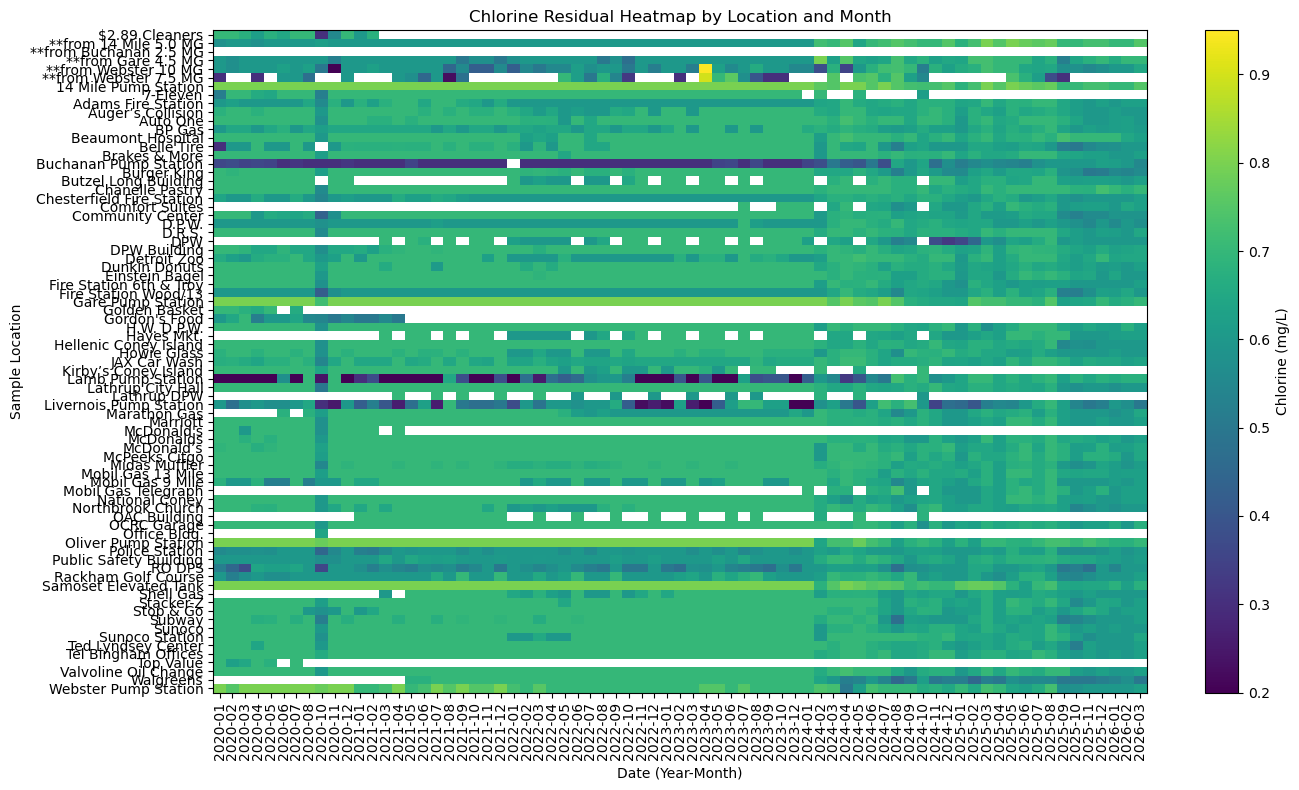

In [92]:
# Plot the heatmap

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

plt.imshow(heatmap_pivot, aspect='auto')

plt.colorbar(label="Chlorine (mg/L)")

plt.yticks(range(len(heatmap_pivot.index)), heatmap_pivot.index)
plt.xticks(
    range(len(heatmap_pivot.columns)),
    heatmap_pivot.columns.astype(str),
    rotation=90
)

plt.title("Chlorine Residual Heatmap by Location and Month")
plt.xlabel("Date (Year-Month)")
plt.ylabel("Sample Location")

plt.tight_layout()
plt.show()

#### Refining Heatmap for Readability

The initial heatmap includes all sample locations and monthly observations, providing a comprehensive view of the dataset. However, due to the high number of locations and time points, the visualization becomes difficult to read and interpret.

To improve clarity and highlight meaningful patterns, the heatmap is refined by:
- Limiting the analysis to distribution system sampling locations, excluding pump stations and elevated tanks
- Aggregating values to a yearly level to reduce visual noise
- Focusing on the most frequently sampled locations
- Sorting locations by average chlorine residual levels

This refined visualization enhances interpretability while preserving the key spatial and temporal insights.

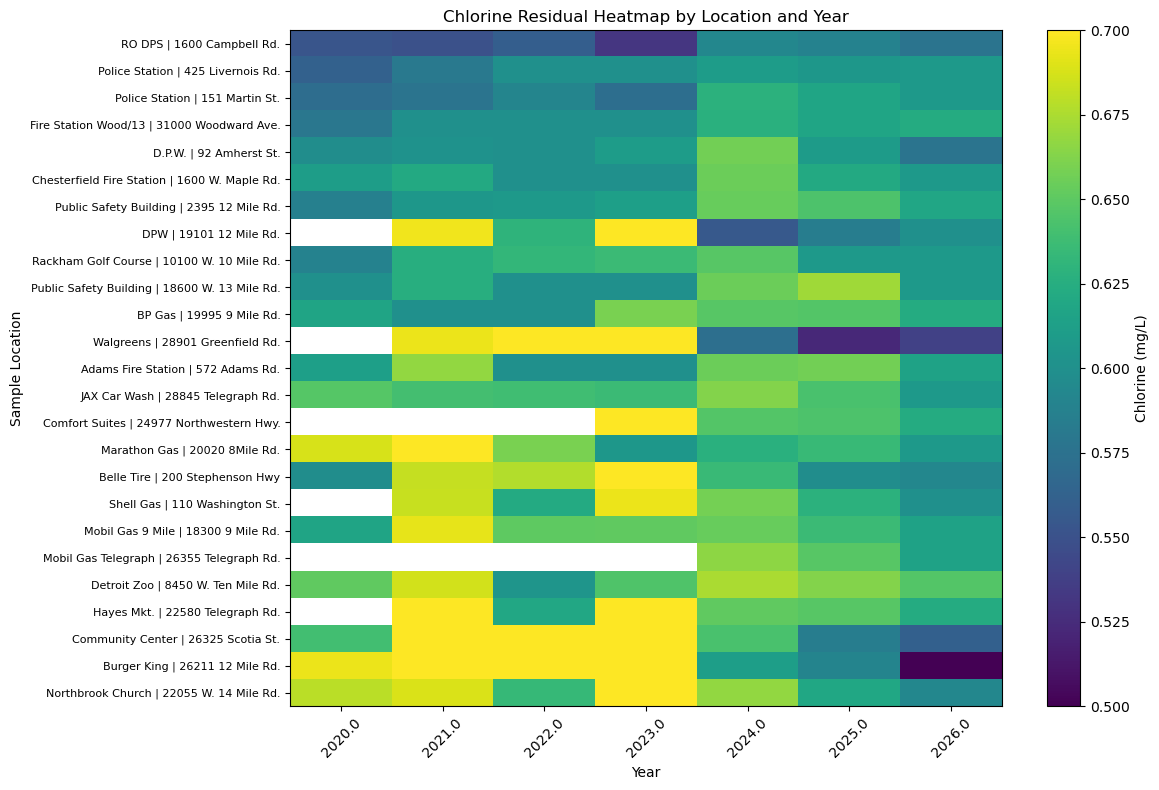

In [100]:
# Use only distribution system sample points
df_heat = df_clean.copy()
df_heat["Location_Type"] = df_heat["Sample_Location"].apply(classify_location)
df_heat = df_heat[df_heat["Location_Type"] == "Distribution"].copy()

# Create clearer unique site label
df_heat["Site_Label"] = (
    df_heat["Sample_Location"].astype(str).str.strip()
    + " | "
    + df_heat["Address"].astype(str).str.strip()
)

# Keep only locations with recent data
recent_cutoff = "2025-01-01"

active_sites = (
    df_heat[df_heat["Date"] >= recent_cutoff]
    ["Site_Label"]
    .unique()
)

df_heat = df_heat[df_heat["Site_Label"].isin(active_sites)].copy()

# Create yearly column
df_heat["Year"] = df_heat["Date"].dt.year

# Aggregate
heatmap_data = (
    df_heat
    .groupby(["Site_Label", "Year"])["Cl2"]
    .mean()
    .reset_index()
)

# Pivot
heatmap_pivot = heatmap_data.pivot(
    index="Site_Label",
    columns="Year",
    values="Cl2"
)

# Sort by average residual
location_order = (
    df_heat
    .groupby("Site_Label")["Cl2"]
    .mean()
    .sort_values()
    .index
)

heatmap_pivot = heatmap_pivot.loc[location_order]

# limit to worst performers for readability
heatmap_pivot = heatmap_pivot.head(25)

# Improving formatting
plt.figure(figsize=(12, 8))

plt.imshow(heatmap_pivot, aspect='auto')

plt.colorbar(label="Chlorine (mg/L)")

plt.yticks(
    range(len(heatmap_pivot.index)),
    heatmap_pivot.index,
    fontsize=8
)

plt.xticks(
    range(len(heatmap_pivot.columns)),
    heatmap_pivot.columns,
    rotation=45
)

plt.title("Chlorine Residual Heatmap by Location and Year")
plt.xlabel("Year")
plt.ylabel("Sample Location")

plt.tight_layout()
plt.show()

#### Interpretation of Heatmap

The refined heatmap provides a clear view of chlorine residual behavior across active distribution system sampling locations over time.

Key observations:

- Chlorine residual levels remain *highly consistent across the system*, with most locations maintaining values within the 0.60–0.70 mg/L range, and exhibiting less variance in recent years than was seen in earlier years.
- Several locations (e.g., RO DPS, Livernois Police Station, Fire Station Wood/13) consistently exhibit *lower residual levels relative to the system average*, indicating stable but lower-end performance likely driven by local hydraulic conditions.
- A small number of locations show *localized changes over time*, most notably Walgreens (Greenfield Rd) and Burger King (12 Mile Rd), where residual levels decline in recent years compared to historical values.
- No evidence of *system-wide degradation* is observed, as residual levels remain stable across all locations during each time period.
- Gaps in the heatmap reflect *changes in the sampling plan* (site additions/removals) rather than performance issues.

Overall, the heatmap reinforces that chlorine residual performance is *stable at the system level*, with variability driven primarily by location-specific characteristics rather than systemic issues.

### Low-End Residual Risk Analysis

To better quantify location-level performance near the lower operational threshold, we calculate the proportion of samples below 0.5 mg/L for each distribution system site.

This metric highlights locations that:

- Frequently approach the lower end of acceptable residual levels
- May be more sensitive to operational or hydraulic variability
- Could warrant targeted monitoring or operational adjustments

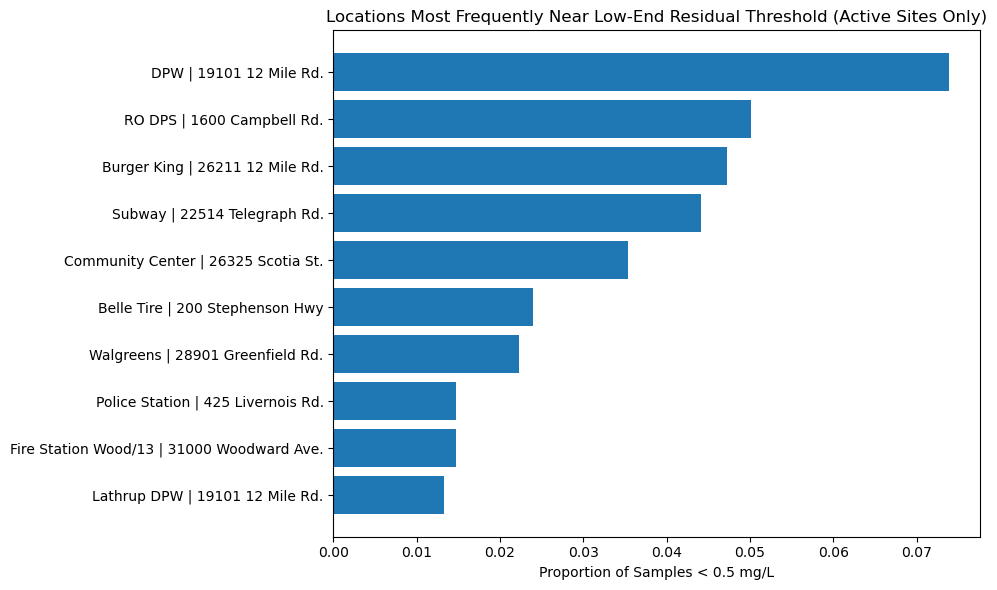

In [103]:
# Define low-end threshold
threshold = 0.5

# Ensure Location_Type exists
df_clean["Location_Type"] = df_clean["Sample_Location"].apply(classify_location)

# Identify active locations based on recent sampling (current sample plan proxy)
recent_cutoff = "2023-01-01"

active_locations = (
    df_clean[df_clean["Date"] >= recent_cutoff]
    .groupby(["Sample_Location", "Address"])
    .size()
    .reset_index()[["Sample_Location", "Address"]]
)

# Calculate low-end performance stats (distribution points + active sites only)
low_end_stats = (
    df_clean[df_clean["Location_Type"] == "Distribution"]
    .merge(
        active_locations,
        on=["Sample_Location", "Address"],
        how="inner"
    )
    .assign(low_flag=lambda x: x["Cl2"] < threshold)
    .groupby(["Sample_Location", "Address"])
    .agg(
        pct_low=("low_flag", "mean"),
        count=("Cl2", "count")
    )
)

# Filter out low sample size locations
low_end_stats = low_end_stats[low_end_stats["count"] >= 50]

# Sort by worst performers
low_end_stats = low_end_stats.sort_values("pct_low", ascending=False)

# Select top 10
top_low = low_end_stats.head(10).reset_index()

# Create labels for plotting
labels = top_low["Sample_Location"] + " | " + top_low["Address"]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(labels, top_low["pct_low"])
plt.xlabel("Proportion of Samples < 0.5 mg/L")
plt.title("Locations Most Frequently Near Low-End Residual Threshold (Active Sites Only)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Resolving Location Naming Inconsistencies

During analysis, certain sampling locations were found to have inconsistent naming conventions (e.g., "DPW" vs. "Lathrup DPW") despite sharing the same physical address.

To ensure accurate aggregation and avoid duplicate representation, location names were standardized using address-based mapping prior to analysis.

This step improves the reliability of location-level metrics and reflects best practices in data cleaning for operational datasets.


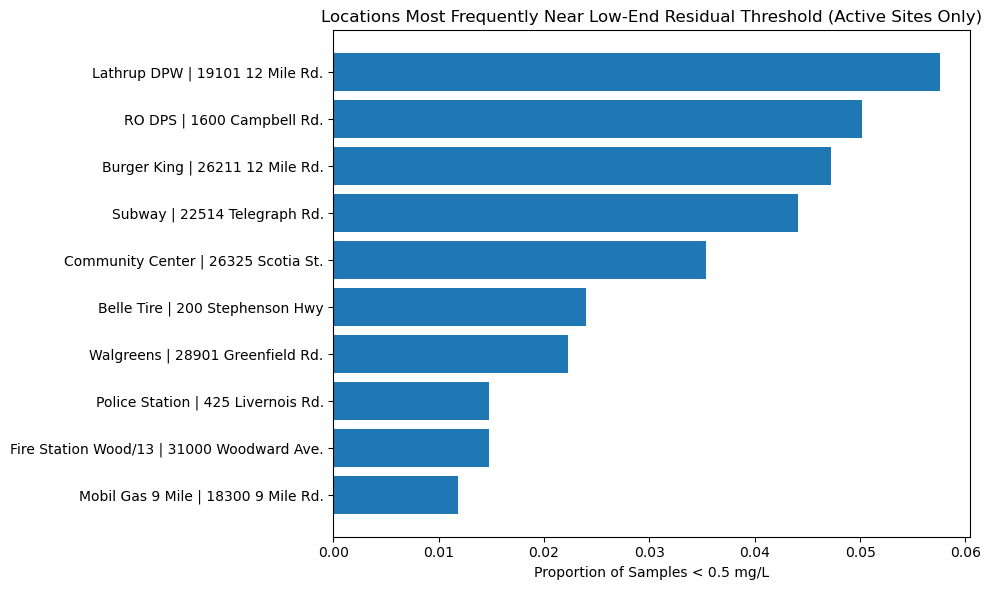

In [104]:
# Define low-end threshold
threshold = 0.5

# Ensure Location_Type exists
df_clean["Location_Type"] = df_clean["Sample_Location"].apply(classify_location)

# --- FIX: Standardize duplicate location names using address ---
df_clean["Sample_Location"] = df_clean.apply(
    lambda row: "Lathrup DPW"
    if row["Address"] == "19101 12 Mile Rd."
    else row["Sample_Location"],
    axis=1
)

# Identify active locations based on recent sampling (current sample plan proxy)
recent_cutoff = "2023-01-01"

active_locations = (
    df_clean[df_clean["Date"] >= recent_cutoff]
    .groupby(["Sample_Location", "Address"])
    .size()
    .reset_index()[["Sample_Location", "Address"]]
)

# Calculate low-end performance stats (distribution points + active sites only)
low_end_stats = (
    df_clean[df_clean["Location_Type"] == "Distribution"]
    .merge(
        active_locations,
        on=["Sample_Location", "Address"],
        how="inner"
    )
    .assign(low_flag=lambda x: x["Cl2"] < threshold)
    .groupby(["Sample_Location", "Address"])
    .agg(
        pct_low=("low_flag", "mean"),
        count=("Cl2", "count")
    )
)

# Filter out low sample size locations
low_end_stats = low_end_stats[low_end_stats["count"] >= 50]

# Sort by worst performers
low_end_stats = low_end_stats.sort_values("pct_low", ascending=False)

# Select top 10
top_low = low_end_stats.head(10).reset_index()

# Create labels for plotting
labels = top_low["Sample_Location"] + " | " + top_low["Address"]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(labels, top_low["pct_low"])
plt.xlabel("Proportion of Samples < 0.5 mg/L")
plt.title("Locations Most Frequently Near Low-End Residual Threshold (Active Sites Only)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Conclusion
#### Overall System Performance

This analysis of chlorine residual data across the distribution system indicates that overall disinfection performance is *stable and well-controlled*. The majority of observations fall within the typical operational range of approximately *0.6–0.7* mg/L, with limited variability over time and across locations.

Time series analysis further supports this, showing consistent mean residual levels and a relatively narrow spread between minimum and maximum values. While occasional deviations occur, there is no evidence of sustained system-wide degradation.

#### Data Quality and Anomaly Handling

A small number of near-zero residual values were identified and investigated. Based on domain knowledge and operational context, these observations were determined to be *unlikely to represent true system conditions*, and were instead attributed to:

- Data recording or transcription errors
- Missed samples incorrectly logged as zero
- Non-representative sampling conditions

Rather than removing these values, they were retained and *flagged as data quality anomalies*, preserving dataset integrity while allowing flexible downstream analysis.

#### Location-Level Insights

Initial location-level comparisons revealed misleading results due to differences in infrastructure type. After classifying sites (e.g., pump stations, reservoirs, distribution points), analysis was refined to focus on *distribution system sampling locations*, ensuring meaningful comparisons.

Key findings include:

- Chlorine residuals are *highly consistent across most locations*, particularly in recent years
- Certain locations consistently operate at the *lower end of the acceptable range*, likely reflecting hydraulic characteristics (e.g., distance from source, dead-end conditions)
- No locations exhibit patterns indicative of persistent or systemic underperformance
  
#### Spatial and Temporal Patterns

Heatmap analysis combining location and time dimensions revealed:

- Strong *system-wide consistency* across years
- Minor location-specific variability, rather than broad system trends
- No clear evidence of seasonal or long-term decline in residual performance

Gaps in the heatmap correspond to changes in the sampling plan (site additions/removals), rather than operational issues.

#### Low-End Residual Risk Assessment

A targeted analysis of low-end performance (proportion of samples below 0.5 mg/L) provided an operationally meaningful metric for identifying potential risk areas.

This analysis showed:

- Most locations rarely approach the low-end threshold
- A small subset of sites more frequently operate near this threshold, but still within acceptable limits
- These locations represent *monitoring priorities*, not immediate concerns
  
### Final Takeaways

- The system maintains *consistent and reliable chlorine residual levels* across both time and space
- Observed variability is driven primarily by *location-specific factors*, not systemic issues
- Data quality challenges were identified and addressed through *transparent, reproducible methods*
- The analysis framework provides a scalable approach for *ongoing monitoring and decision support*
  
#### Potential Next Steps
- Incorporate hydraulic or distance-to-source data to further explain location-level variability
- Develop automated alerts for locations exceeding low-end thresholds
- Integrate this analysis into routine reporting workflows for continuous system monitoring